In [202]:
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-white')
%matplotlib inline
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import classification_report, confusion_matrix

In [203]:
df = pd.read_csv('data/cardiac_failure_processed.csv')

In [204]:
print(df.shape)
df.head()

(70000, 14)


,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0,0.588076,2,168,62.0,110,80,1,1,0,0,1,0
1,1,1,0.730159,1,156,85.0,140,90,3,1,0,0,1,1
2,2,2,0.624003,1,165,64.0,130,70,3,1,0,0,0,1
3,3,3,0.528455,2,169,82.0,150,100,1,1,0,0,1,1
4,4,4,0.516918,1,156,56.0,100,60,1,1,0,0,0,0


In [205]:
df.drop(columns=['Unnamed: 0', 'id'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  float64
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  int64  
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  int64  
 5   ap_lo        70000 non-null  int64  
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 6.4 MB


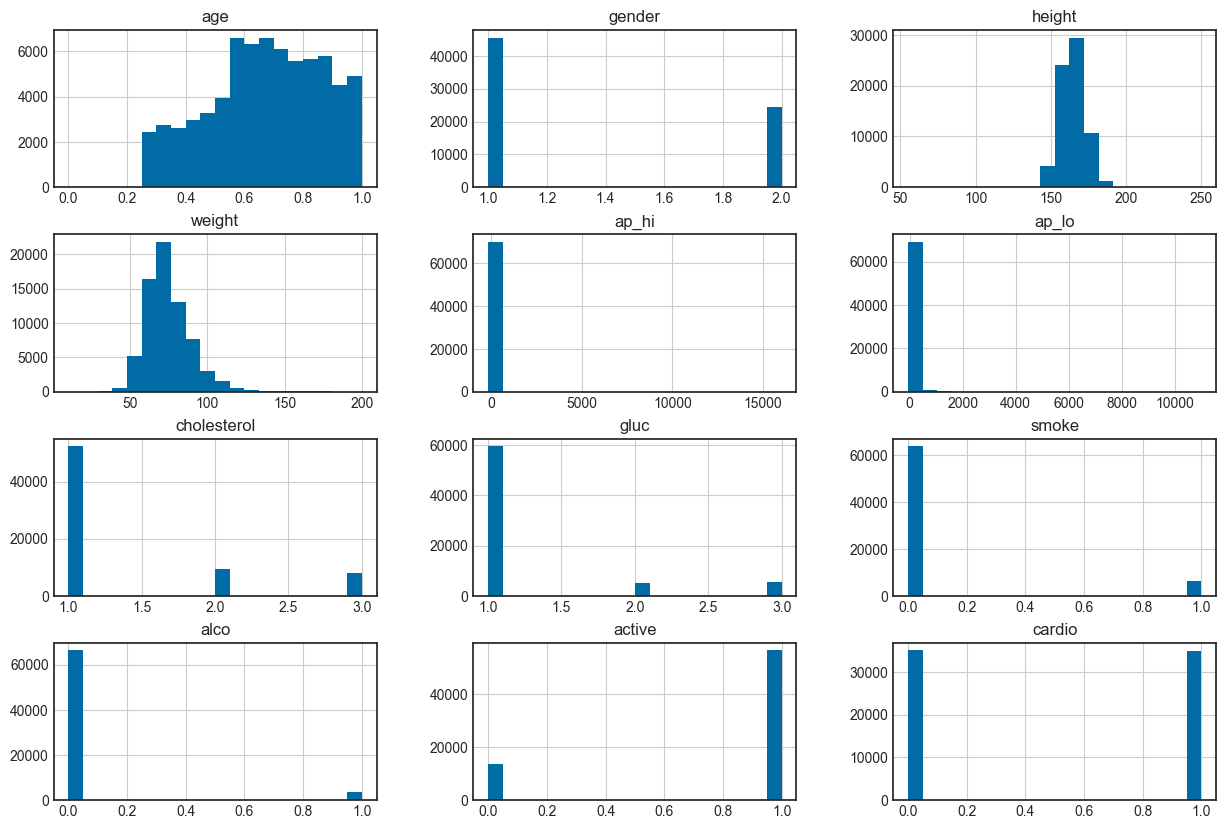

In [206]:
df.hist(figsize=(15, 10), bins=20)
plt.show()

In [207]:
df['gender'] = df['gender'].map({1: 1, 2: 0})
df['height'] = df['height'].astype(float)
df['ap_hi'] = df['ap_hi'].astype(float)
df['ap_lo'] = df['ap_lo'].astype(float)

In [208]:
one_hot_encoder = OneHotEncoder(sparse_output=False, drop='first')
one_hot_encoder.fit(df[['cholesterol', 'gluc']])
encoded_features = one_hot_encoder.transform(df[['cholesterol', 'gluc']])
encoded_df = pd.DataFrame(encoded_features, columns=one_hot_encoder.get_feature_names_out(['cholesterol', 'gluc']))
df = pd.concat([df.drop(columns=['cholesterol', 'gluc']), encoded_df.astype(int)], axis=1)
df.head()

,age,gender,height,weight,ap_hi,ap_lo,smoke,alco,active,cardio,cholesterol_2,cholesterol_3,gluc_2,gluc_3
0,0.588076,0,168.0,62.0,110.0,80.0,0,0,1,0,0,0,0,0
1,0.730159,1,156.0,85.0,140.0,90.0,0,0,1,1,0,1,0,0
2,0.624003,1,165.0,64.0,130.0,70.0,0,0,0,1,0,1,0,0
3,0.528455,0,169.0,82.0,150.0,100.0,0,0,1,1,0,0,0,0
4,0.516918,1,156.0,56.0,100.0,60.0,0,0,0,0,0,0,0,0


In [209]:
feature_list = list(df.columns)
feature_list.remove('cardio')
df = df[feature_list + ['cardio']]
df.head()

,age,gender,height,weight,ap_hi,ap_lo,smoke,alco,active,cholesterol_2,cholesterol_3,gluc_2,gluc_3,cardio
0,0.588076,0,168.0,62.0,110.0,80.0,0,0,1,0,0,0,0,0
1,0.730159,1,156.0,85.0,140.0,90.0,0,0,1,0,1,0,0,1
2,0.624003,1,165.0,64.0,130.0,70.0,0,0,0,0,1,0,0,1
3,0.528455,0,169.0,82.0,150.0,100.0,0,0,1,0,0,0,0,1
4,0.516918,1,156.0,56.0,100.0,60.0,0,0,0,0,0,0,0,0


In [210]:
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=['cardio']),
    df['cardio'],
    test_size=0.2,
    random_state=42,
    stratify=df['cardio']
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=int(df.shape[0]*.2),
    random_state=42,
    stratify=y_train
)

print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

Training set shape: (42000, 13) (42000,)
Validation set shape: (14000, 13) (14000,)
Test set shape: (14000, 13) (14000,)


In [211]:
standard_scaler = StandardScaler()
standard_scaler.fit(X_train.select_dtypes(include=[float]))
X_train_scaled = pd.DataFrame(standard_scaler.transform(X_train.select_dtypes(include=[float])), columns=X_train.select_dtypes(include=[float]).columns)
X_val_scaled = pd.DataFrame(standard_scaler.transform(X_val.select_dtypes(include=[float])), columns=X_val.select_dtypes(include=[float]).columns)
X_test_scaled = pd.DataFrame(standard_scaler.transform(X_test.select_dtypes(include=[float])), columns=X_test.select_dtypes(include=[float]).columns)

In [212]:
X_train_scaled = pd.concat([X_train_scaled, X_train.select_dtypes(include=[int]).reset_index(drop=True)], axis=1)
X_val_scaled = pd.concat([X_val_scaled, X_val.select_dtypes(include=[int]).reset_index(drop=True)], axis=1)
X_test_scaled = pd.concat([X_test_scaled, X_test.select_dtypes(include=[int]).reset_index(drop=True)], axis=1)

In [213]:
def val_performance(model, X_val_scaled, y_val):
    y_val_pred = model.predict(X_val_scaled)

    matrix = confusion_matrix(y_val, y_val_pred)

    fig, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title('Confusion Matrix - Validation Set')
    plt.show()

    return y_val_pred

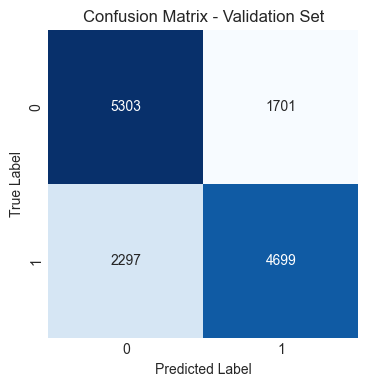

In [214]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_val_pred_lr = val_performance(lr, X_val_scaled, y_val)

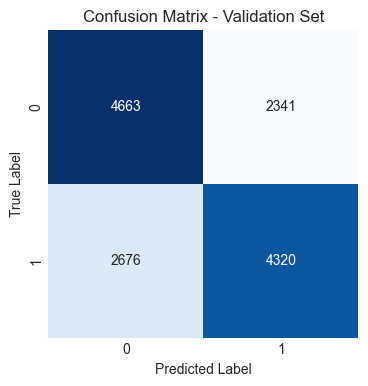

In [215]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_val_pred_knn = val_performance(knn, X_val_scaled, y_val)

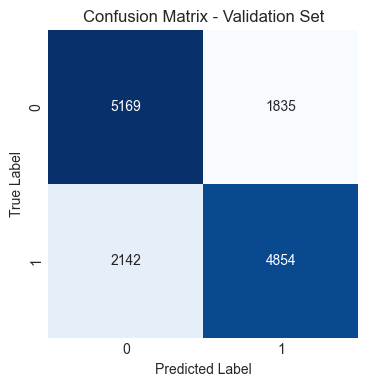

In [216]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_val_pred_rf = val_performance(rf, X_val_scaled, y_val)

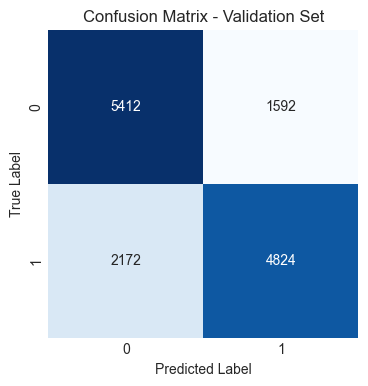

In [217]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_scaled, y_train)
y_val_pred_gb = val_performance(gb, X_val_scaled, y_val)

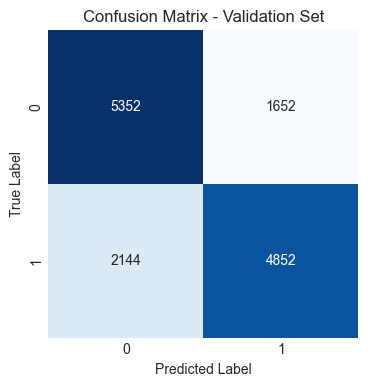

In [218]:
svc = SVC(random_state=42)
svc.fit(X_train_scaled, y_train)
y_val_pred_svc = val_performance(svc, X_val_scaled, y_val)

<Axes: ylabel='height'>

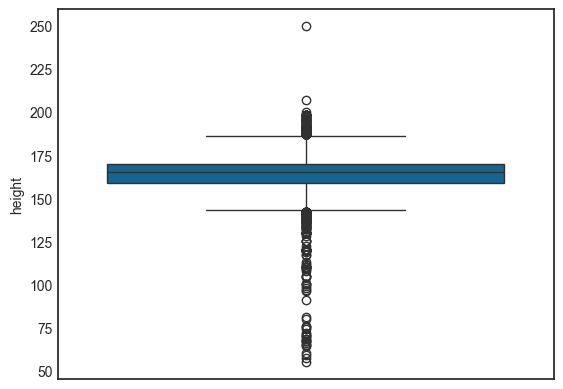

In [183]:
sns.boxplot(df['height'])

<Axes: ylabel='height'>

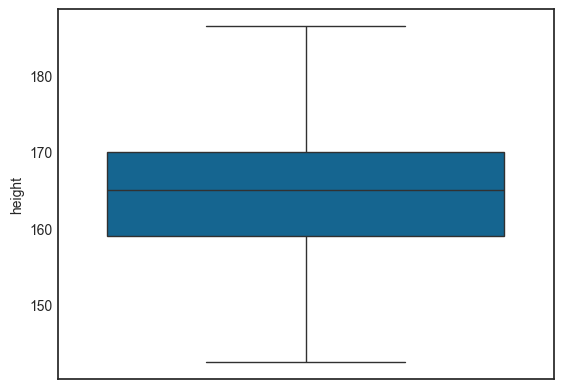

In [184]:
height_IQR = df['height'].quantile(0.75) - df['height'].quantile(0.25)
height_lower_bound = df['height'].quantile(0.25) - (1.5 * height_IQR)
height_upper_bound = df['height'].quantile(0.75) + (1.5 * height_IQR)

df['height'] = np.where(df['height'] < height_lower_bound, height_lower_bound, df['height'])
df['height'] = np.where(df['height'] > height_upper_bound, height_upper_bound, df['height'])

sns.boxplot(df['height'])